In [ ]:
import json

DATA_INFO_PATH = "/mnt/dataset4/ziling/RNN/course_project/MDD/dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [ ]:
import h5py
import numpy as np
DATA_NAME = "MDD"
INDEX_PATH_TRAIN = f"/mnt/dataset4/ziling/RNN/course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"/mnt/dataset4/ziling/RNN/course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"/mnt/dataset4/ziling/RNN/course_project/{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (960, 20, 200)
y dtype: int64
y shape: (960,)
unique: [0 1]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [13]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        time_points=200,
        num_classes,
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [7]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [ ]:
from RNN import EEGGRU

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


Epoch [01/20] | Train Loss: 0.7752 | Val Loss: 0.5004 | Val Acc: 0.7391
Epoch [02/20] | Train Loss: 0.4345 | Val Loss: 0.5111 | Val Acc: 0.7438
Epoch [03/20] | Train Loss: 0.3764 | Val Loss: 0.5170 | Val Acc: 0.7438
Epoch [04/20] | Train Loss: 0.2991 | Val Loss: 0.5090 | Val Acc: 0.7578
Epoch [05/20] | Train Loss: 0.2816 | Val Loss: 0.5274 | Val Acc: 0.7438
Epoch [06/20] | Train Loss: 0.2527 | Val Loss: 0.5137 | Val Acc: 0.7828
Epoch [07/20] | Train Loss: 0.1904 | Val Loss: 0.5179 | Val Acc: 0.7797
Epoch [08/20] | Train Loss: 0.1576 | Val Loss: 0.5539 | Val Acc: 0.7719
Epoch [09/20] | Train Loss: 0.1557 | Val Loss: 0.5824 | Val Acc: 0.7656
Epoch [10/20] | Train Loss: 0.1392 | Val Loss: 0.5858 | Val Acc: 0.7688
Epoch [11/20] | Train Loss: 0.1184 | Val Loss: 0.5981 | Val Acc: 0.7734
Epoch [12/20] | Train Loss: 0.1188 | Val Loss: 0.6095 | Val Acc: 0.7766
Epoch [13/20] | Train Loss: 0.1259 | Val Loss: 0.6727 | Val Acc: 0.7406
Epoch [14/20] | Train Loss: 0.1203 | Val Loss: 0.6572 | Val Acc:

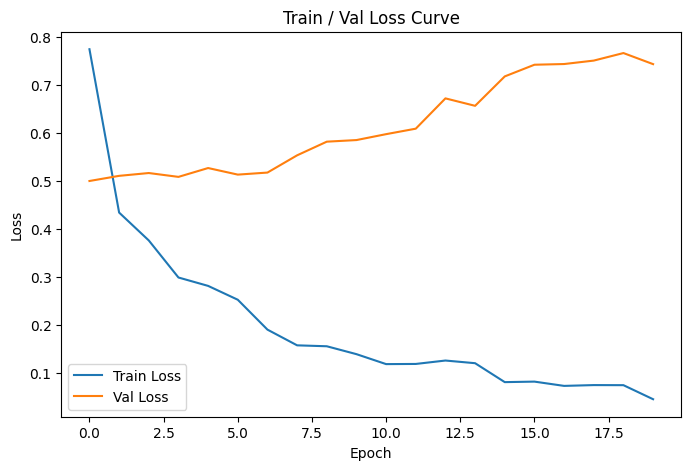

----------------------------------------
Test input shape: torch.Size([1, 20, 200])
Test output shape: torch.Size([1, 2])


In [15]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from course_project.TEST_DATASET import TrainDataset, TestDataset


CHANNELS = 20
patch_size = 200
CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4

# -------------------------
# 数据
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 模型、损失、优化器
# -------------------------
model = SimpleMLP(input_channels=CHANNELS,time_points=200,num_classes=CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------
# 记录曲线
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []

# -------------------------
# 训练循环
# -------------------------
for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_num = 0

    for data, label in train_loader:
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    train_losses.append(epoch_train_loss)

    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

# -------------------------
# 输出最终 val accuracy
# -------------------------
print("\n" + "-" * 40)
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

# -------------------------
# 画 train / val loss 曲线
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.legend()
plt.show()


# -------------------------
# test 推理示例
# -------------------------
test_data = next(iter(test_loader))
test_pred = model(test_data)
print("-" * 40)
print("Test input shape:", test_data.shape)
print("Test output shape:", test_pred.shape)

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [8]:
# -------------------------
# 保存 test 预测标签（每行一个数字）
# -------------------------
model.eval()
output_path = f'course_project/{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")


Saved 800 labels to: course_project/MDD/MDD.txt
